<a href="https://colab.research.google.com/github/ldaniel-hm/eml_tabular/blob/main/MonteCarloTodasLasVisitas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **SARSA con Políticas epsilon-soft**

Este notebook describe un experimento de aprendizaje por refuerzo utilizando el algoritmo de SARSA con políticas epsilon-soft. El propósito de este análisis es entrenar un agente en un entorno de gym con el juego "CliffWalking", un entorno estándar en el que el agente debe aprender a moverse a través de un mapa en busca de una meta, evitando obstáculos.

## **1. Preparación del Entorno**

La preparación consta de las siguientes partes:
- **Instalación de Dependencias**: Se instalan las librerías necesarias para utilizar el entorno `gymnasium` para la simulación, con el objetivo de crear un ambiente controlado para que el agente pueda interactuar.
- **Importación de Librerías**: Se importan las bibliotecas necesarias como `numpy` para el manejo de matrices y `matplotlib` para la visualización de los resultados.

- **Importación del Entorno "CliffWalking"**:
Se carga el entorno "CliffWalking".

- **Funciones para Mostrar los Resultados**: Se define una función para graficar la proporción de recompensas obtenidas en cada episodio del entrenamiento. Esto ayuda a visualizar el progreso del agente en términos de su desempeño durante el entrenamiento.

##### **Código de la Instalación e Importación**
----

In [1]:
%%capture
#@title Instalamos gym
%pip install 'gym[box2d]==0.20.0'

## Instalación de algunos paquetes.
#!apt-get update
## Para usar gymnasium[box2d]
#!apt install swig
#!pip install gymnasium[box2d]

In [2]:
#@title Importamos librerias
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import gymnasium as gym

In [3]:
#@title Importamos el cliff walking
# https://gymnasium.farama.org/environments/toy_text/cliff_walking/
env_discrete = gym.make("CliffWalking-v1", render_mode = "ansi")

# Acciones
UP, RIGHT, DOWN, LEFT = 0,1,2,3

## **2. Diseño del Agente**

El diseño del agente consta de dos partes, el algoritmo con el que aprende y las políticas (toma de decisiones) que realiza.

- **Políticas del Agente**
  - **Política epsilon-soft**: Se define una política donde todas las acciones tienen una probabilidad de ser elegida.
  - **Política epsilon-greedy**: basada en la política epsilon-soft. De esta forma el agente tiene una pequeña probabilidad de explorar (tomar una acción aleatoria) y una mayor probabilidad de explotar (tomar la acción que considera mejor). Esto permite equilibrar la exploración y la explotación.
  - **Política greedy**: Es la usada una vez que "ha aprendido".

- **Algoritmo SARSA**
  - Se implementa el algoritmo SARSA como método de control basado en diferencias temporales (TD).
  - Se trata de un método "on-policy", ya que la actualización se realiza utilizando la misma política epsilon-greedy con la que el agente interactúa con el entorno.
  - La actualización de los valores Q se realiza de forma incremental en cada paso del episodio, utilizando una tasa de aprendizaje constante $\alpha$.
  - La actualización se basa en la transición $(s, a, r, s', a')$, empleando el valor estimado de la siguiente acción seleccionada por la política.

#### **Código de las políticas y algoritmo SARSA**
----------------

In [4]:
# @title Políticas del agente

# Política epsilon-soft. Se usa para el entrenamiento
def random_epsilon_greedy_policy(Q, epsilon, state, nA):
    pi_A = np.ones(nA, dtype=float) * epsilon / nA
    best_action = np.argmax(Q[state])
    pi_A[best_action] += (1.0 - epsilon)
    return pi_A

# Política epsilon-greedy a partir de una epsilon-soft
def epsilon_greedy_policy(Q, epsilon, state, nA):
    pi_A = random_epsilon_greedy_policy(Q, epsilon, state, nA)
    return np.random.choice(np.arange(nA), p=pi_A)

# Política Greedy a partir de los valones Q. Se usa para mostrar la solución.
def pi_star_from_Q(env, Q):
    done = False
    pi_star = np.zeros([env.observation_space.n, env.action_space.n])
    state, info = env.reset() # start in top-left, = 0
    actions = ""
    while not done:
        action = np.argmax(Q[state, :])
        actions += f"{action}, "
        pi_star[state,action] = action
        state, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated
    return pi_star, actions

In [5]:
def sarsa_algorithm(env, num_episodes=5000, alpha=0.5, epsilon=0.1, discount_factor=1.0, decay=True):
    nA = env.action_space.n
    nS = env.observation_space.n
    Q = np.zeros((nS, nA))
    episode_lengths = []
    rewards_per_episode = []

    for t in tqdm(range(num_episodes)):
        state, info = env.reset(seed=100)

        # Decaimiento de epsilon
        if decay:
            current_epsilon = max(0.05, epsilon * (0.995 ** t))
        else:
            current_epsilon = epsilon

        action = epsilon_greedy_policy(Q, current_epsilon, state, nA)
        done = False
        total_reward = 0
        step_count = 0

        while not done:
            next_state, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated
            total_reward += reward
            step_count += 1

            # Próxima acción usando ε-greedy
            next_action = epsilon_greedy_policy(Q, current_epsilon, next_state, nA)

            # Actualización SARSA
            Q[state, action] += alpha * (reward + discount_factor * Q[next_state, next_action] - Q[state, action])

            state = next_state
            action = next_action

        rewards_per_episode.append(total_reward)
        episode_lengths.append(step_count)

    return Q, rewards_per_episode, episode_lengths

## **3. Experimentación**

- En esta sección, el algoritmo SARSA con política epsilon (con decaimiento) se ejecuta para el entorno de Cliff Walking.

- Se realiza un entrenamiento con un número determinado de episodios (5000 en concreto).

- Además, se prueba el escenario con epsilon con decaimiento exponencial suave de acuerdo a la expresión:
    $$ \epsilon_t = \max(0.05, \epsilon_0 \cdot 0.995^t) $$

- Durante el entrenamiento hay una visualización de la recompensa acumulada media por episodio a lo largo del entrenamiento.

- Junto a dicho volcado se muestra gráficamente la evolución de la recompensa media obtenida.

- También se hace un volcado de los valores Q de cada estado, donde se muestra cómo el agente valora diferentes acciones en distintos estados del entorno, lo que puede interpretarse como su conocimiento sobre las mejores estrategias para alcanzar la meta evitando caer en el acantilado.

- Además, se muestra la política óptima derivada de los valores Q. Esta política es la que el agente seguiría si tuviera que elegir siempre la acción que maximiza su recompensa esperada (o equivalentemente, minimiza la penalización acumulada).

### **3.1 Representaciones Gráficas**

Se mostrará la función $f(t) = \frac{\sum_{i=1}^t R_i}{t}$ para $t = 1,2,\ldots, NumeroEpisodios$. Aquí, $R_i$ es la recompensa obtenida en el episodio $i$. Como las recompensas son negativas por cada paso y caídas en el acantilado, esta función reflejará la calidad del aprendizaje, es decir, cuán eficientemente el agente alcanza el objetivo evitando el acantilado.

In [6]:
# @title Funciones para mostrar los resultados

def plot(list_stats):
  # Creamos una lista de índices para el eje x
  indices = list(range(len(list_stats)))

  # Creamos el gráfico
  plt.figure(figsize=(6, 3))
  plt.plot(indices, list_stats)

  # Añadimos título y etiquetas
  plt.title('Proporción de recompensas')
  plt.xlabel('Episodio')
  plt.ylabel('Proporción')

  # Mostramos el gráfico
  plt.grid(True)
  plt.show()

# Nueva función: tamaño de los episodios
def plot_episodes(episode_lengths, window=200):
    plt.figure(figsize=(6,3))

    # Longitud real por episodio
    plt.plot(episode_lengths, label="Longitud episodio")

    # Media móvil (curva de tendencia)
    moving_avg = np.convolve(
        episode_lengths,
        np.ones(window)/window,
        mode='valid'
    )

    plt.plot(moving_avg, linewidth=2, label="Tendencia (media móvil)")
    plt.xlabel("Episodio")
    plt.ylabel("Longitud del episodio")
    plt.title("Evolución de la longitud de los episodios")
    plt.legend()
    plt.grid()
    plt.show()

### **3.2 Experimentación en el escenario con ϵ-decaimiento**

- Se realizan 5000 episodios y se actualizan los valores Q (valor de acción) de forma incremental en cada paso del episodio, utilizando el método SARSA basado en diferencias temporales. Se aplica una política $\epsilon$-greedy sobre una política $\epsilon$-soft con un valor $\epsilon$ decreciente.

In [7]:
# @title Aprendizaje
Q_sarsa, rewards_sarsa, episode_lengths_sarsa = sarsa_algorithm(env_discrete, num_episodes=5000, alpha=0.5, epsilon=0.1, discount_factor=0.95)

100%|██████████| 5000/5000 [00:10<00:00, 455.22it/s]


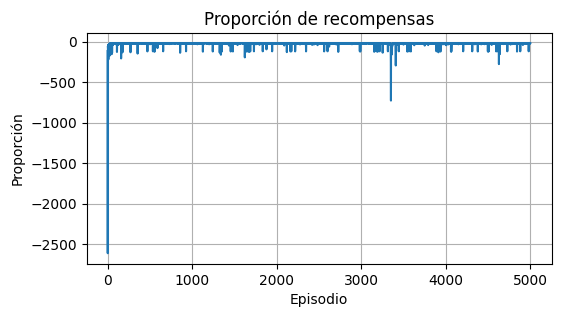

Máxima proporcion: -17


In [8]:
#@title Proporción de aciertos por número de episodios
plot(rewards_sarsa)
print(f"Máxima proporcion: {rewards_sarsa[-1]}")

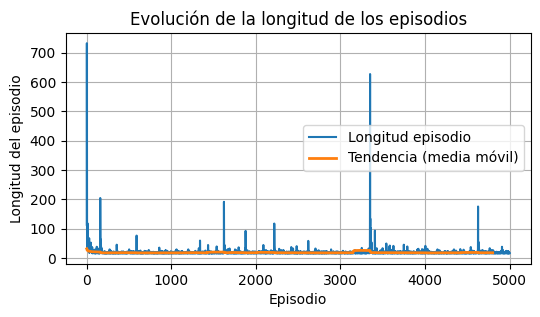

In [9]:
#@title Longitud de episodio por número de episodios
plot_episodes(episode_lengths_sarsa)

In [10]:
# @title Tabla de valores Q
print("Valores Q para cada estado:\n", Q_sarsa)

Valores Q para cada estado:
 [[ -11.67301715  -11.33389164  -12.3350604   -12.1482876 ]
 [ -11.21820208  -10.08479337  -11.21127061  -11.64207127]
 [ -11.29816473   -9.42982952  -11.22579116  -11.13267473]
 [ -10.79149031   -8.80995469  -10.97484283  -11.08768797]
 [  -9.49168527   -8.44372245  -10.22609293  -10.51703006]
 [ -10.15559256   -8.10730596  -10.04668201   -9.95880207]
 [  -8.67086722   -7.48694901   -9.20935649   -9.78929269]
 [  -8.04193692   -6.44746386   -8.23765988   -8.71251643]
 [  -7.08123191   -5.3199951    -7.36356977   -8.16488833]
 [  -6.01906529   -4.52461608   -6.5618295    -7.29000985]
 [  -5.94668123   -3.70989045   -5.54988695   -6.59588544]
 [  -4.34695181   -5.05172478   -2.8525       -6.13485969]
 [ -11.78112191  -11.40631335  -13.13231887  -11.92913661]
 [ -10.79372706  -11.12079999  -11.69483757  -11.93455829]
 [ -10.36278167  -12.16951911  -30.50452761  -14.08419599]
 [ -13.5962727   -10.24114241  -13.60254779  -12.65263963]
 [ -13.3222264   -10.234427

In [11]:
# @title Política final
pi_sarsa, actions_sarsa  = pi_star_from_Q(env_discrete, Q_sarsa)
print("Política óptima obtenida\n", pi_sarsa, f"\n Acciones {actions_sarsa } \n Para el siguiente grid\n", env_discrete.render())
print()

Política óptima obtenida
 [[0. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 1. 0. 0.]
 [0. 1. 0. 0.]
 [0. 1. 0. 0.]
 [0. 1. 0. 0.]
 [0. 1. 0. 0.]
 [0. 1. 0. 0.]
 [0. 1. 0. 0.]
 [0. 1. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 2. 0.]
 [0. 1. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 2. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 2. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]] 
 Acciones 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2,  
 Para el siguiente grid
 o  o  o  o  o  o  o  o  o  o  o  o
o  o  o  o  o  o  o  o  o  o  o  o
o  o  o  o  o  o  o  o  o  o  o  o
o  C  C  C  C  C  C  C  C  C  C  x





### **3.3 Experimentación en el escenario sin ϵ-decaimiento**

- Se realizan 5000 episodios y se actualizan los valores Q (valor de acción) de forma incremental en cada paso del episodio mediante el método de diferencias temporales (SARSA). Se aplica una política $\epsilon$-greedy sobre una política $\epsilon$-soft con un valor $\epsilon$ constante.

In [12]:
# @title Aprendizaje
Q_sarsa, rewards_sarsa, episode_lengths_sarsa = sarsa_algorithm(env_discrete, num_episodes=5000, alpha=0.5, epsilon=0.1, decay=False, discount_factor=0.95)

100%|██████████| 5000/5000 [00:08<00:00, 595.20it/s]


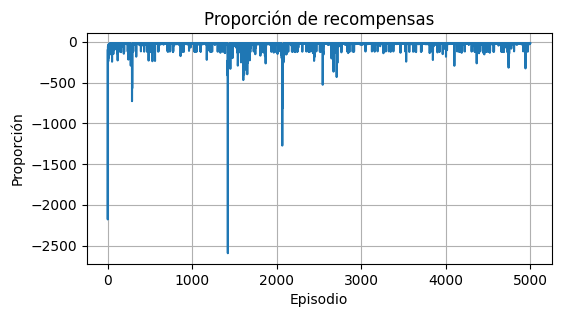

Máxima proporcion: -17


In [13]:
#@title Proporción de aciertos por número de episodios
plot(rewards_sarsa)
print(f"Máxima proporcion: {rewards_sarsa[-1]}")

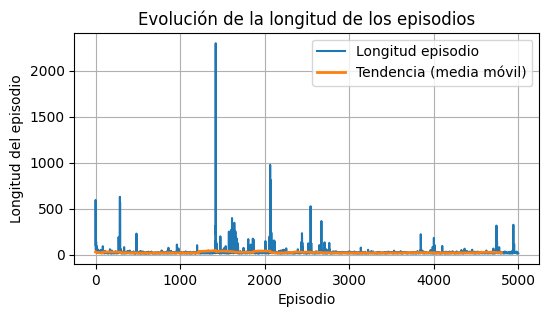

In [14]:
#@title Longitud de episorio por número de episodios
plot_episodes(episode_lengths_sarsa)

In [15]:
# @title Tabla de valores Q
print("Valores Q para cada estado:\n", Q_sarsa)

Valores Q para cada estado:
 [[ -15.99872373  -16.01115123  -14.27399403  -15.9668894 ]
 [ -14.43026301  -11.41733328  -14.51193402  -15.48574983]
 [ -13.91424383  -10.34556863  -15.80892157  -14.01608638]
 [ -13.38711961   -9.35539127  -14.27879942  -12.54158551]
 [ -12.19687016   -8.57308345  -12.30847391  -13.69287043]
 [ -10.81112053   -7.75660633  -13.6156722   -13.9182197 ]
 [ -13.72208124   -6.85810066  -11.22973893  -11.58115103]
 [ -10.14237488   -6.04921006  -10.75350377   -9.96546438]
 [  -7.32814634   -5.30181882  -10.86273278   -8.82180992]
 [  -6.27615994   -4.79356651   -7.21111383   -8.02977666]
 [  -6.32154354   -6.7061232    -3.99256625   -6.87878693]
 [  -5.97609154   -5.85255235   -5.97342507   -5.17340006]
 [ -15.66245805  -13.00807708  -15.86218315  -15.84799101]
 [ -12.27863233  -14.30807132  -14.86245573  -15.76992609]
 [ -13.75561577  -11.58955428  -16.69243339  -15.58210585]
 [ -15.009589    -11.4271333   -15.0448591   -35.8253281 ]
 [ -10.31077102  -12.937865

In [16]:
# @title Política final
pi_sarsa, actions_sarsa = pi_star_from_Q(env_discrete, Q_sarsa)
print("Política óptima obtenida\n", pi_sarsa, f"\n Acciones {actions_sarsa} \n Para el siguiente grid\n", env_discrete.render())
print()

Política óptima obtenida
 [[0. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 1. 0. 0.]
 [0. 1. 0. 0.]
 [0. 1. 0. 0.]
 [0. 1. 0. 0.]
 [0. 1. 0. 0.]
 [0. 1. 0. 0.]
 [0. 1. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 2. 0.]
 [0. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 2. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 2. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]] 
 Acciones 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 2, 2,  
 Para el siguiente grid
 o  o  o  o  o  o  o  o  o  o  o  o
o  o  o  o  o  o  o  o  o  o  o  o
o  o  o  o  o  o  o  o  o  o  o  o
o  C  C  C  C  C  C  C  C  C  C  x





## **4. Fin**